# Imports

In [1]:
!pip install -U safetensors


In [1]:
import os
import gc
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    log_loss,
)

from datasets import Dataset as HFDataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    DataCollatorWithPadding,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Seq2SeqTrainingArguments,
    Trainer,
)

import evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


ModuleNotFoundError: No module named 'sklearn'

# Load unified datasets

In [3]:
BASE_DIR = r"C:\Users\HP\Unified Bangla\Unified Bangla Dataset"  

train_path = os.path.join(BASE_DIR, "Unified_train_dataset.csv")
val_path   = os.path.join(BASE_DIR, "Unified_validation_dataset.csv")
test_path  = os.path.join(BASE_DIR, "Unified_test_dataset.csv")

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

for df in (train_df, val_df, test_df):
    df.columns = df.columns.str.strip()

print(train_df.columns)
train_df.head()


Index(['bangla_speech', 'barishal_bangla_speech', 'chittagong_bangla_speech',
       'mymensingh_bangla_speech', 'noakhali_bangla_speech',
       'sylhet_bangla_speech'],
      dtype='object')


,bangla_speech,barishal_bangla_speech,chittagong_bangla_speech,mymensingh_bangla_speech,noakhali_bangla_speech,sylhet_bangla_speech
0,কেমন আছো ?,আসো কোরোহম?,কেন আচো?,কেমত আছো?,কেইক্কান আছেন ?,ভালা আছনি?
1,আজকে আমার মন ভালো নেই,আইজ মোর মনডা ভালোনা,আযিয়া আর মন বালা নাই?,আইজ আমার মন ভালা নাই,আইজ্জা আর মন ভালা নাই,আইজকু আমার মন ভালা নায়
2,তুমি কি করো ?,ও মোনু হর কি?,তুঁই কি গরো?,তুমি কিতা করো?,তুমি কিআ করর ?,তুমি কিতা খরো?
3,এই গরমে আমার কিছু ভালো লাগে না,এই থাডা পরা গরমে মোর কিস্সু ভাল্লাগেনা,এই গরমত আত্তুন কিচু বালা ন লাগের,এই গরমডাত আমার কিছু ভালা লাগে না,এতো গরমে আর কিচ্ছু ভালা লাগে না,অউ গরমো আমার কুনতা ভালা লাগের না
4,ছেলেটি সাদা রঙয়ের একটি শার্ট পরে এসেছিল,পলাউগ্গা এউক্কা ধলা রং এর এউক্কা গুন্জি পইর্রা...,ফোয়াইবা সাদা রংওর উজ্ঞা শার্ট ফরি আইস্যিল,ছেড়াটা সাদা রংগের একটা শার্ট পইড়া আইছিল,পোলাডা একটা সাদা রং এর শার্ট পড়ি আইসিলো,ফুয়াটায় এখটা সাদা রংগর শার্ট পিন্দিয়া আইছিল


# A. Dialect Detection (BanglaBERT + DistilBERT)

## Build dialect detection DataFrames

In [4]:
DIALECTS = ["standard", "barishal", "chittagong", "mymensingh", "noakhali", "sylhet"]

DIALECT2COL = {
    "standard bangla":   "bangla_speech",
    "barishal":   "barishal_bangla_speech",
    "chittagong": "chittagong_bangla_speech",
    "mymensingh": "mymensingh_bangla_speech",
    "noakhali":   "noakhali_bangla_speech",
    "sylhet":     "sylhet_bangla_speech",
}

def normalize_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # 1) Strip whitespace from column names
    df.columns = df.columns.str.strip()
    # 2) Strip whitespace from all string cells
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].astype(str).str.strip()
            # Convert "nan"/"None" strings back to NaN
            df.loc[df[c].isin(["nan", "NaN", "None", ""]), c] = np.nan
    return df

train_df = normalize_df(train_df)
val_df   = normalize_df(val_df)
test_df  = normalize_df(test_df)

def build_detection_df(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    # safer and faster than iterrows for large sets:
    for dialect, col in DIALECT2COL.items():
        if col not in df.columns:
            raise ValueError(f"Missing column after stripping whitespace: {col}")

        series = df[col].dropna().astype(str).str.strip()
        series = series[series != ""]
        rows.extend([{"text": t, "dialect": dialect} for t in series.tolist()])

    out = pd.DataFrame(rows)
    out = out.dropna(subset=["text", "dialect"]).reset_index(drop=True)
    return out

det_train_df = build_detection_df(train_df)
det_val_df   = build_detection_df(val_df)
det_test_df  = build_detection_df(test_df)

print(len(det_train_df), len(det_val_df), len(det_test_df))
print(det_train_df.head())


11250 1500 2250
                                      text          dialect
0                               কেমন আছো ?  standard bangla
1                    আজকে আমার মন ভালো নেই  standard bangla
2                            তুমি কি করো ?  standard bangla
3           এই গরমে আমার কিছু ভালো লাগে না  standard bangla
4  ছেলেটি সাদা রঙয়ের একটি শার্ট পরে এসেছিল  standard bangla


## Encode labels and convert to HF datasets

In [5]:
label_encoder = LabelEncoder()

det_train_df["label"] = label_encoder.fit_transform(det_train_df["dialect"])
det_val_df["label"]   = label_encoder.transform(det_val_df["dialect"])
det_test_df["label"]  = label_encoder.transform(det_test_df["dialect"])

num_labels = len(label_encoder.classes_)
print("Dialects:", label_encoder.classes_, "| num_labels =", num_labels)

train_det_ds = HFDataset.from_pandas(det_train_df[["text", "dialect", "label"]])
val_det_ds   = HFDataset.from_pandas(det_val_df[["text", "dialect", "label"]])
test_det_ds  = HFDataset.from_pandas(det_test_df[["text", "dialect", "label"]])


NameError: name 'LabelEncoder' is not defined

## Metrics function (shared by both dialect models)

In [5]:
def compute_metrics_classification(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    # log_loss should know the full label set
    ll = log_loss(labels, probs, labels=list(range(num_labels)))

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "log_loss": ll,
    }


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def plot_confusion_matrix(trainer, dataset, title="Confusion Matrix"):
    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    labels = pred_out.label_ids
    preds = np.argmax(logits, axis=-1)

    cm = confusion_matrix(labels, preds)
    cm_norm = confusion_matrix(labels, preds, normalize="true")

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(
        ax=ax[0], xticks_rotation=45, values_format="d"
    )
    ax[0].set_title(title + " (Raw)")

    ConfusionMatrixDisplay(cm_norm, display_labels=label_encoder.classes_).plot(
        ax=ax[1], xticks_rotation=45, values_format=".2f"
    )
    ax[1].set_title(title + " (Normalized)")

    plt.tight_layout()
    plt.show()

    print("\nClassification report:\n")
    print(classification_report(labels, preds, target_names=label_encoder.classes_, digits=4))


## BanglaBERT dialect detector

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BERT_CKPT = "csebuetnlp/banglabert"

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_CKPT)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_CKPT,
    num_labels=num_labels,
    use_safetensors=True,  
).to(device)


def bert_preprocess(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=128)

train_det_bert = train_det_ds.map(bert_preprocess, batched=True)
val_det_bert   = val_det_ds.map(bert_preprocess, batched=True)
test_det_bert  = test_det_ds.map(bert_preprocess, batched=True)

data_collator_bert = DataCollatorWithPadding(bert_tokenizer)

bert_args = TrainingArguments(
    output_dir="models/banglabert_dialect",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    fp16=False,
    bf16=False,
    dataloader_num_workers=0,
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=train_det_bert,
    eval_dataset=val_det_bert,
    tokenizer=bert_tokenizer,
    data_collator=data_collator_bert,
    compute_metrics=compute_metrics_classification,
)


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/11250 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

C:\Users\tisra\AppData\Local\Temp\ipykernel_5224\1061734224.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  bert_trainer = Trainer(


## Train, evaluate, save BanglaBERT and clean up

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Log Loss,Runtime,Samples Per Second,Steps Per Second
1,0.569700,0.556566,0.835333,0.838150,0.835333,0.835376,0.556566,41.884400,35.813000,2.244000
2,0.398300,0.548372,0.845333,0.853706,0.845333,0.844450,0.548372,46.107100,32.533000,2.039000
3,0.303200,0.544617,0.870000,0.872345,0.870000,0.869516,0.544617,45.795400,32.754000,2.053000


BanglaBERT dialect test metrics: {'eval_loss': 0.6696435809135437, 'eval_accuracy': 0.8475555555555555, 'eval_precision': 0.8529847790680914, 'eval_recall': 0.8475555555555555, 'eval_f1': 0.8438630639049722, 'eval_log_loss': 0.669643579086988, 'eval_runtime': 77.3116, 'eval_samples_per_second': 29.103, 'eval_steps_per_second': 1.824, 'epoch': 3.0}


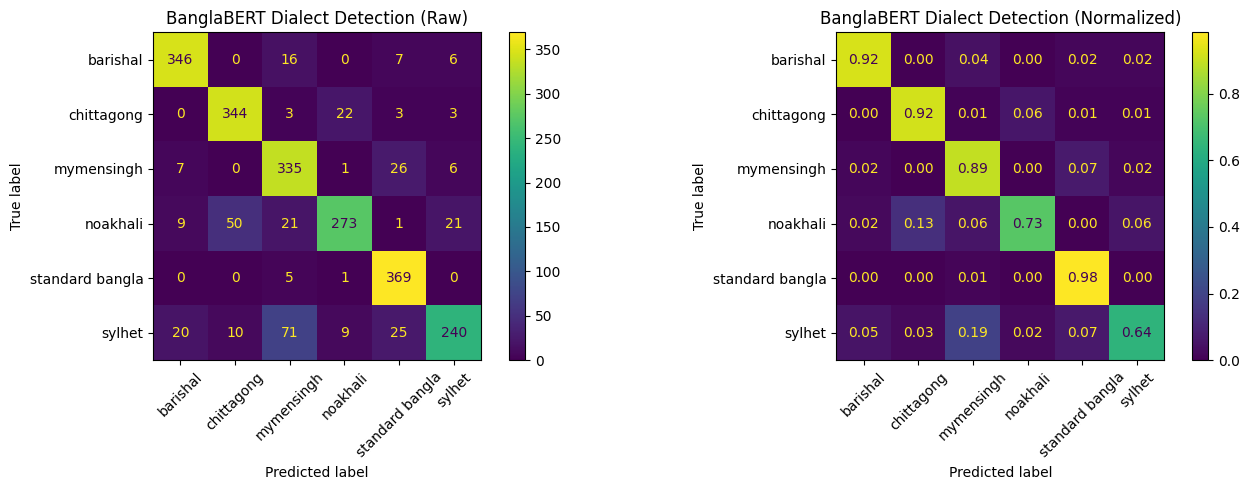


Classification report:

                 precision    recall  f1-score   support

       barishal     0.9058    0.9227    0.9141       375
     chittagong     0.8515    0.9173    0.8832       375
     mymensingh     0.7428    0.8933    0.8111       375
       noakhali     0.8922    0.7280    0.8018       375
standard bangla     0.8561    0.9840    0.9156       375
         sylhet     0.8696    0.6400    0.7373       375

       accuracy                         0.8476      2250
      macro avg     0.8530    0.8476    0.8439      2250
   weighted avg     0.8530    0.8476    0.8439      2250

Saved label classes to: saved_models/banglabert_dialect\label_classes.txt
Removing checkpoint: models/banglabert_dialect\checkpoint-1407
Removing checkpoint: models/banglabert_dialect\checkpoint-2814
Removing checkpoint: models/banglabert_dialect\checkpoint-4221
Cleanup done.


In [10]:
# Train
bert_trainer.train()

# Evaluate on test
bert_metrics = bert_trainer.evaluate(test_det_bert)
print("BanglaBERT dialect test metrics:", bert_metrics)

# Confusion matrix (raw + normalized) + classification report
plot_confusion_matrix(bert_trainer, test_det_bert, title="BanglaBERT Dialect Detection")

# Save model (SAFE: uses safetensors)
save_dir_bert = "saved_models/banglabert_dialect"
os.makedirs(save_dir_bert, exist_ok=True)

# Save in safetensors format to avoid torch.load CVE restriction
bert_model.save_pretrained(save_dir_bert, safe_serialization=True)
bert_tokenizer.save_pretrained(save_dir_bert)

# Save label mapping for inference later
label_map_path = os.path.join(save_dir_bert, "label_classes.txt")
with open(label_map_path, "w", encoding="utf-8") as f:
    for cls in label_encoder.classes_:
        f.write(cls + "\n")
print("Saved label classes to:", label_map_path)

# Delete extra checkpoints to save disk space
ckpt_root = bert_args.output_dir
if os.path.isdir(ckpt_root):
    import shutil
    for name in os.listdir(ckpt_root):
        if name.startswith("checkpoint-"):
            ckpt_path = os.path.join(ckpt_root, name)
            print("Removing checkpoint:", ckpt_path)
            shutil.rmtree(ckpt_path, ignore_errors=True)

# Release memory
del bert_trainer, bert_model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("Cleanup done.")


# Load DistilBERT + tokenize

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
import os, gc, numpy as np, torch

DISTIL_CKPT = "distilbert-base-multilingual-cased"

distil_tokenizer = AutoTokenizer.from_pretrained(DISTIL_CKPT)
distil_model = AutoModelForSequenceClassification.from_pretrained(
    DISTIL_CKPT,
    num_labels=num_labels,
    use_safetensors=True,   
).to(device)

def distil_preprocess(batch):
    return distil_tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

train_det_distil = train_det_ds.map(distil_preprocess, batched=True)
val_det_distil   = val_det_ds.map(distil_preprocess, batched=True)
test_det_distil  = test_det_ds.map(distil_preprocess, batched=True)

data_collator_distil = DataCollatorWithPadding(distil_tokenizer)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

model.safetensors:  14%|#3        | 73.4M/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/11250 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

# TrainingArguments + Trainer

In [13]:
distil_args = TrainingArguments(
    output_dir="models/distilbert_dialect",
    eval_strategy="epoch",          
    save_strategy="epoch",
    learning_rate=3e-5,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    fp16=False,
    bf16=False,
    dataloader_num_workers=0,
)

distil_trainer = Trainer(
    model=distil_model,
    args=distil_args,
    train_dataset=train_det_distil,
    eval_dataset=val_det_distil,
    tokenizer=distil_tokenizer,
    data_collator=data_collator_distil,
    compute_metrics=compute_metrics_classification,
)


C:\Users\tisra\AppData\Local\Temp\ipykernel_5224\420531227.py:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  distil_trainer = Trainer(


# Train + Evaluate + Confusion Matrix + Save + Cleanup

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Log Loss,Runtime,Samples Per Second,Steps Per Second
1,0.553700,0.539251,0.816667,0.826318,0.816667,0.818471,0.539251,37.352900,40.158000,2.517000
2,0.406800,0.559904,0.834000,0.838386,0.834000,0.832753,0.559904,37.078300,40.455000,2.535000
3,0.275000,0.539399,0.857333,0.857573,0.857333,0.856696,0.539399,35.918400,41.761000,2.617000


DistilBERT dialect test metrics: {'eval_loss': 0.7447038888931274, 'eval_accuracy': 0.8346666666666667, 'eval_precision': 0.8468474795942669, 'eval_recall': 0.8346666666666666, 'eval_f1': 0.8283228549447603, 'eval_log_loss': 0.7447038500823817, 'eval_runtime': 69.9154, 'eval_samples_per_second': 32.182, 'eval_steps_per_second': 2.017, 'epoch': 3.0}


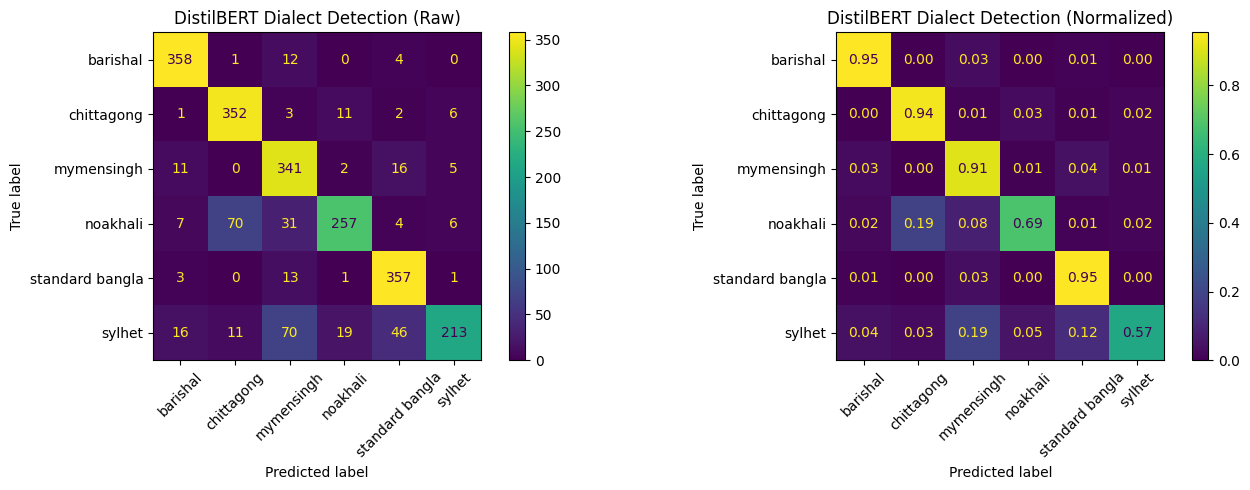


Classification report:

                 precision    recall  f1-score   support

       barishal     0.9040    0.9547    0.9287       375
     chittagong     0.8111    0.9387    0.8702       375
     mymensingh     0.7255    0.9093    0.8071       375
       noakhali     0.8862    0.6853    0.7729       375
standard bangla     0.8322    0.9520    0.8881       375
         sylhet     0.9221    0.5680    0.7030       375

       accuracy                         0.8347      2250
      macro avg     0.8468    0.8347    0.8283      2250
   weighted avg     0.8468    0.8347    0.8283      2250

Saved label classes to: saved_models/distilbert_dialect\label_classes.txt
Removing checkpoint: models/distilbert_dialect\checkpoint-1407
Removing checkpoint: models/distilbert_dialect\checkpoint-2814
Removing checkpoint: models/distilbert_dialect\checkpoint-4221
Cleanup done.


In [14]:
distil_trainer.train()

distil_metrics = distil_trainer.evaluate(test_det_distil)
print("DistilBERT dialect test metrics:", distil_metrics)

# Confusion matrix
plot_confusion_matrix(distil_trainer, test_det_distil, title="DistilBERT Dialect Detection")

# Save model
save_dir_distil = "saved_models/distilbert_dialect"
os.makedirs(save_dir_distil, exist_ok=True)

distil_model.save_pretrained(save_dir_distil, safe_serialization=True)
distil_tokenizer.save_pretrained(save_dir_distil)

# Save label mapping
label_map_path = os.path.join(save_dir_distil, "label_classes.txt")
with open(label_map_path, "w", encoding="utf-8") as f:
    for cls in label_encoder.classes_:
        f.write(cls + "\n")
print("Saved label classes to:", label_map_path)

# delete extra checkpoints to save disk space
ckpt_root = distil_args.output_dir
if os.path.isdir(ckpt_root):
    import shutil
    for name in os.listdir(ckpt_root):
        if name.startswith("checkpoint-"):
            ckpt_path = os.path.join(ckpt_root, name)
            print("Removing checkpoint:", ckpt_path)
            shutil.rmtree(ckpt_path, ignore_errors=True)

# release memory
del distil_trainer, distil_model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("Cleanup done.")
